In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

# Any results you write to the current directory are saved as output.

['train.csv', 'sample_submission.csv', 'test.csv']


In [2]:
import tensorflow as tf
print(tf.__version__)

import pandas as pd
import numpy as np

1.13.1


In [3]:
train_df = pd.read_csv('../input/train.csv')
test_df = pd.read_csv('../input/test.csv')
train_df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,...,pixel744,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
test_df.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel744,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
y_train = train_df.label.values
x_train = train_df.drop(columns=["label"]).values
x_test = test_df.values
x_train[:10]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [6]:
print(x_train.shape)
print(x_test.shape)
print(max(x_train[1]))

(42000, 784)
(28000, 784)
255


In [7]:
x_train = x_train / 255.0
x_test = x_test / 255.0
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(784,)),
    # tf.keras.layers.Dense(2048, activation=tf.nn.relu),
    # tf.keras.layers.Dense(1024, activation=tf.nn.relu),
    # tf.keras.layers.Dense(512, activation=tf.nn.relu),
    tf.keras.layers.Dense(256, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])


Instructions for updating:
Colocations handled automatically by placer.


In [8]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('acc') > 0.997):
            print("\n Reached 99% accuracy so cancelling training!")
            self.model.stop_training = True


model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=['accuracy'])
model.fit(x_train, y_train, epochs=30)


Epoch 1/30
42000/42000 [==============================] - 6s 149us/sample - loss: 0.2337 - acc: 0.9302
Epoch 2/30
42000/42000 [==============================] - 6s 142us/sample - loss: 0.0950 - acc: 0.9704
Epoch 3/30
42000/42000 [==============================] - 6s 143us/sample - loss: 0.0630 - acc: 0.9795
Epoch 4/30
42000/42000 [==============================] - 6s 143us/sample - loss: 0.0454 - acc: 0.9851
Epoch 5/30
42000/42000 [==============================] - 6s 146us/sample - loss: 0.0345 - acc: 0.9886
Epoch 6/30
42000/42000 [==============================] - 6s 150us/sample - loss: 0.0300 - acc: 0.9898
Epoch 7/30
42000/42000 [==============================] - 6s 144us/sample - loss: 0.0240 - acc: 0.9923
Epoch 8/30
42000/42000 [==============================] - 6s 142us/sample - loss: 0.0194 - acc: 0.9936
Epoch 9/30
42000/42000 [==============================] - 6s 142us/sample - loss: 0.0187 - acc: 0.9936
Epoch 10/30
42000/42000 [==============================] - 6s 140us/sampl

In [9]:
classifications = model.predict(x_test)

In [10]:
classifications.shape
classifications
np.argmax(classifications, axis=1)[0]

2

In [11]:
def write_submissions(file_name, imageId, predictions):
    
    output = pd.DataFrame({
        'ImageId': imageId, 'Label': predictions
    })
    output.to_csv(file_name, index=False)
    
    
write_submissions('submission_1.csv', pd.Series(range(1,28001)), np.argmax(classifications, axis=1))

## CNN

In [12]:
y_train = train_df.label.values
x_train = train_df.drop(columns=["label"]).values
x_test = test_df.values

In [13]:
print(x_train.shape)
print(x_test.shape)

(42000, 784)
(28000, 784)


In [14]:
x_train = x_train.reshape(42000, 28, 28, 1)
x_test = x_test.reshape(28000, 28, 28, 1)

x_train = x_train / 255.0
x_test = x_test / 255.0

In [15]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    # tf.keras.layers.Dense(2048, activation='relu'),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    # tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 64)        640       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 13, 13, 64)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 11, 11, 64)        36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 5, 5, 64)          0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 1600)              0         
_________________________________________________________________
dense_3 (Dense)              (None, 1024)              1639424   
_________________________________________________________________
dense_4 (Dense)              (None, 512)               524800    
__________

In [16]:
model.fit(x_train, y_train, epochs=20)

Epoch 1/20
42000/42000 [==============================] - 9s 226us/sample - loss: 0.1352 - acc: 0.9574
Epoch 2/20
42000/42000 [==============================] - 8s 198us/sample - loss: 0.0534 - acc: 0.9850
Epoch 3/20
42000/42000 [==============================] - 8s 200us/sample - loss: 0.0379 - acc: 0.9892
Epoch 4/20
42000/42000 [==============================] - 8s 198us/sample - loss: 0.0284 - acc: 0.9919
Epoch 5/20
42000/42000 [==============================] - 8s 200us/sample - loss: 0.0265 - acc: 0.9931
Epoch 6/20
42000/42000 [==============================] - 8s 197us/sample - loss: 0.0205 - acc: 0.9942
Epoch 7/20
42000/42000 [==============================] - 8s 197us/sample - loss: 0.0179 - acc: 0.9951
Epoch 8/20
42000/42000 [==============================] - 8s 199us/sample - loss: 0.0168 - acc: 0.9956
Epoch 9/20
42000/42000 [==============================] - 8s 197us/sample - loss: 0.0149 - acc: 0.9962
Epoch 10/20
42000/42000 [==============================] - 8s 201us/sampl

In [17]:
classifications = model.predict(x_test)
write_submissions('submission_2.csv', pd.Series(range(1,28001)), np.argmax(classifications, axis=1))

In [18]:
print(y_train[:100])
x_train.shape

[1 0 1 4 0 0 7 3 5 3 8 9 1 3 3 1 2 0 7 5 8 6 2 0 2 3 6 9 9 7 8 9 4 9 2 1 3
 1 1 4 9 1 4 4 2 6 3 7 7 4 7 5 1 9 0 2 2 3 9 1 1 1 5 0 6 3 4 8 1 0 3 9 6 2
 6 4 7 1 4 1 5 4 8 9 2 9 9 8 9 6 3 6 4 6 2 9 1 2 0 5]


(42000, 28, 28, 1)

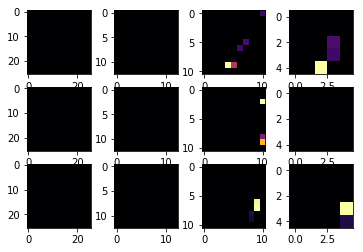

In [19]:
import matplotlib.pyplot as plt
f, axarr = plt.subplots(3, 4)
FIRST_IMAGE = 0
SECOND_IMAGE = 7
THIRD_IMAGE = 8
CONVOLUTION_NUMBER = 1

from tensorflow.keras import models
layer_outputs = [layer.output for layer in model.layers]
activation_model = tf.keras.models.Model(inputs=model.input, outputs=layer_outputs)

for x in range(0, 4):
    f1 = activation_model.predict(x_train[FIRST_IMAGE].reshape(1, 28, 28, 1))[x]
    axarr[0, x].imshow(f1[0, :, :, CONVOLUTION_NUMBER], cmap='inferno')
    axarr[0, x].grid(False)
    f2 = activation_model.predict(x_train[SECOND_IMAGE].reshape(1, 28, 28, 1))[x]
    axarr[1, x].imshow(f2[0, :, :, CONVOLUTION_NUMBER], cmap='inferno')
    axarr[1, x].grid(False)
    f3 = activation_model.predict(x_train[THIRD_IMAGE].reshape(1, 28, 28, 1))[x]
    axarr[2, x].imshow(f3[0, :, :, CONVOLUTION_NUMBER], cmap='inferno')
    axarr[2, x].grid(False)
    